<a href="https://colab.research.google.com/github/JulioClemente/customer-insights-purchase-behavior/blob/main/Customer_Behavior_%26_Satisfaction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

## Customer Behavior Analysis

This project aims to explore customer purchasing behavior and satisfaction using a comprehensive dataset that includes consumption patterns, demographics, and engagement metrics. The analysis focuses on three main insights:

**Relationship between purchase frequency and satisfaction:**
Customers with **middle income levels** show higher satisfaction in their purchases. This suggests that marketing strategies targeting higher-income groups, or initiatives that balance the needs of different income segments, could help improve overall customer satisfaction.

**Impact of income level on satisfaction and average spending:**
Customers in the **High income group** purchase more frequently, even though they show slightly lower satisfaction levels. This difference is small and likely reflects the higher number of High-income customers in the dataset. It is recommended to:

* Improve the shopping experience for High-income customers to further increase their satisfaction;
* Strengthen marketing efforts targeting Middle-income customers to increase their representation and boost overall revenue.

**Influence of purchase channel on customer experience:**
The **online channel** shows the highest average satisfaction, followed by the **mixed channel**. In terms of purchase volume, the mixed channel leads, indicating that although the digital experience is more satisfying, many transactions still occur in a hybrid format. It is recommended to:

* Focus on continuously improving online and mixed channels, ensuring a high-quality digital experience;
* Enhance the physical store experience, while prioritizing strategies that strengthen digital engagement, where satisfaction and interaction levels are higher.

---



# Data and Libraries


##  Importing Libraries


In [3]:
# Data analysis library
import pandas as pd

# Data visualization library
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Ecommerce_Consumer_Behavior_Analysis_Data.csv')

# Understanding the Data

---




In [5]:
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

 Selecting Key Features for Analysis and Insight Generation

In [7]:
df["Income_Level"].value_counts()

,count
Income_Level,
High,515
Middle,485


### Insight on Income Distribution

When analyzing the number of customers by income level, we observe that the High group is slightly larger, with a difference of approximately 30 customers compared to the Medium group. Considering that the dataset contains 1,000 entries, this difference is relatively small and should not significantly impact the overall analysis.



In [8]:
colunas_insights = [
    "Age",
    "Gender",
    "Income_Level",
    "Customer_Satisfaction",
    "Frequency_of_Purchase",
    "Purchase_Channel"
]
df_insights = df[colunas_insights]
df_insights


,Age,Gender,Income_Level,Customer_Satisfaction,Frequency_of_Purchase,Purchase_Channel
0,22,Female,Middle,7,4,Mixed
1,49,Male,High,5,11,In-Store
2,24,Female,Middle,7,2,Mixed
3,29,Female,Middle,1,6,Mixed
4,33,Female,Middle,10,6,Mixed
...,...,...,...,...,...,...
995,44,Female,High,4,5,Online
996,50,Female,High,6,9,Mixed
997,26,Male,High,6,10,Mixed
998,21,Female,High,5,12,In-Store


## 1. Satisfaction Level by Income



In [9]:
# Grouping and calculating the average
satisfaction_by_income = df_insights.groupby("Income_Level")["Customer_Satisfaction"].mean().reset_index()

satisfaction_by_income

,Income_Level,Customer_Satisfaction
0,High,5.207767
1,Middle,5.602062


/tmp/ipykernel_894/2329411405.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Average Satisfaction')

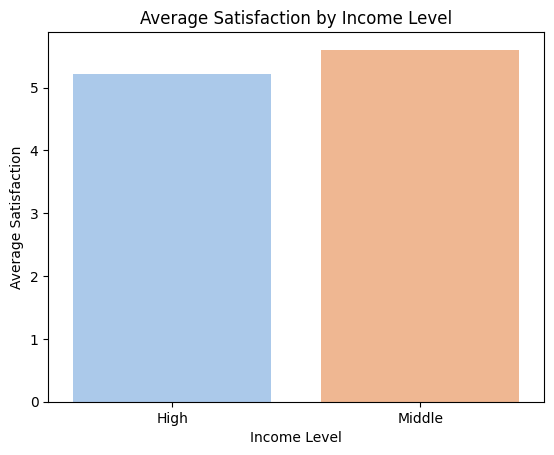

In [10]:
sns.barplot(
    data=satisfaction_by_income,
    x="Income_Level",
    y="Customer_Satisfaction",
    palette="pastel"
)

plt.title("Average Satisfaction by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Average Satisfaction")



### 1.1 Insight

It is observed that customers with middle income levels show higher satisfaction in their purchases. This suggests that marketing strategies targeting higher-income groups, or the implementation of initiatives that balance the needs of different income segments, may help improve overall customer satisfaction.

## 2.0. Purchase Frequency

In [11]:
Purchase_Frequency = df_insights.groupby("Income_Level")[["Customer_Satisfaction", "Frequency_of_Purchase"]].mean()
Purchase_Frequency

,Customer_Satisfaction,Frequency_of_Purchase
Income_Level,,
High,5.207767,7.048544
Middle,5.602062,6.835052


### 2.1 Insight

When analyzing purchase frequency by income level, we observe that customers in the High income group purchase more frequently, even though they show slightly lower satisfaction levels. However, this difference is small and likely reflects the higher number of High-income customers in the dataset.

This observation suggests that High-income customers have greater purchasing power, allowing for more frequent purchases, while Middle-income customers, despite having higher satisfaction, have lower purchasing capacity.

Therefore, recommended strategies include:

Improving the shopping experience for High-income customers to further increase their satisfaction;
Strengthening marketing efforts targeted at Middle-income customers, aiming to increase the number of customers in this segment and, consequently, boost overall revenue.

## 3.0 Satisfaction by Purchase Channel

In [12]:
channel_summary = df_insights.groupby("Purchase_Channel")["Customer_Satisfaction"].agg(["mean", "median", "count"]).reset_index()
channel_summary

,Purchase_Channel,mean,median,count
0,In-Store,5.239264,5.0,326
1,Mixed,5.379412,5.5,340
2,Online,5.574850,6.0,334


/tmp/ipykernel_894/2799995054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


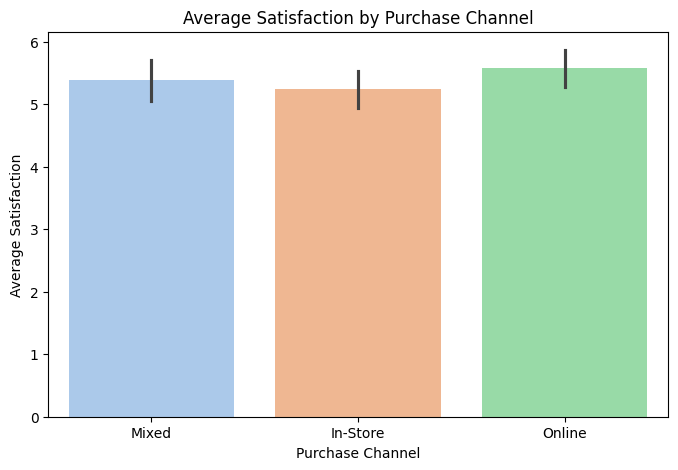

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_insights,
    x="Purchase_Channel",
    y="Customer_Satisfaction",
    palette="pastel"
)

plt.title("Average Satisfaction by Purchase Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Average Satisfaction")

plt.show()

### 3.1 Insight

The analysis indicates that the **online channel** has the highest average customer satisfaction, followed by the **mixed channel**. In terms of purchase volume, the mixed channel leads, showing that although the digital experience is more satisfying, many transactions still occur in a hybrid format.

These results suggest that the company should:

- Focus on continuously improving online and mixed channels, ensuring a high-quality digital experience;

- Enhance the physical store experience, while prioritizing strategies that strengthen digital engagement, where satisfaction and interaction levels are higher

# Conclusion

The analysis provides actionable insights into customer satisfaction, purchase behavior, and channel preferences, guiding marketing strategy, experience improvements, and revenue optimization.